# Test 

Venant du site : https://ipython-books.github.io/134-simulating-a-stochastic-differential-equation/

In [46]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [47]:
sigma = 1.  # Standard deviation.
mu = 10.  # Mean.
tau = .05  # Time constant.

In [48]:
dt = .001  # Time step.
T = 1.  # Total time.
n = int(T / dt)  # Number of time steps.
t = np.linspace(0., T, n)  # Vector of times.

In [49]:
sigma_bis = sigma * np.sqrt(2. / tau)
sqrtdt = np.sqrt(dt)

In [50]:
x = np.zeros(n)

In [51]:
for i in range(n - 1):
    x[i + 1] = x[i] + dt*(-(x[i] - mu) / tau) + sigma_bis * sqrtdt * np.random.randn()

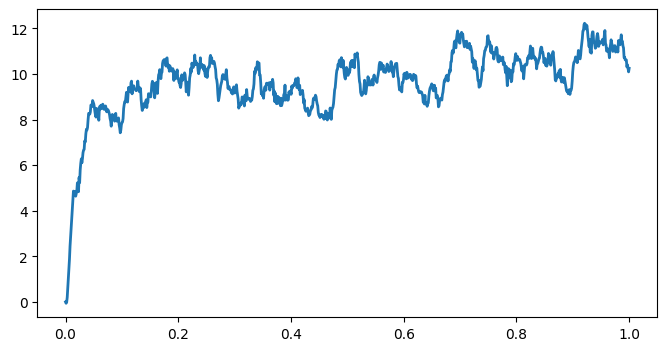

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(t, x, lw=2)

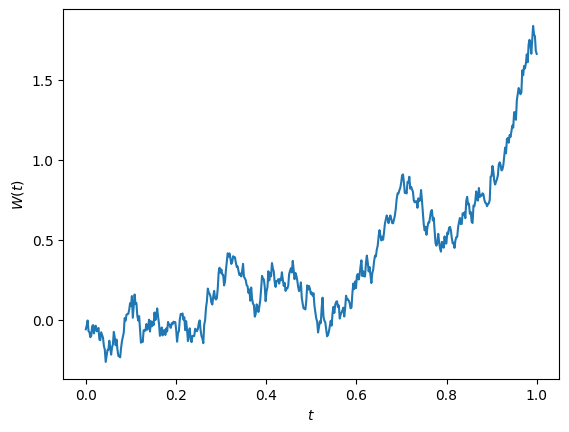

In [53]:
T = 1.0 # End time
N = 500 # Number of steps
dt = T / N
t = np.linspace(0, T, N)

dW = np.sqrt(dt) * np.random.randn(N) # All increments are independent, so initialize the lot in one go
W = np.cumsum(dW) # The Brownian motion is the cumulative sum of all increments

plt.plot(t, W)
plt.xlabel(r'$t$')
plt.ylabel(r'$W(t)$')

plt.show()

Average error is 0.007915000862336319


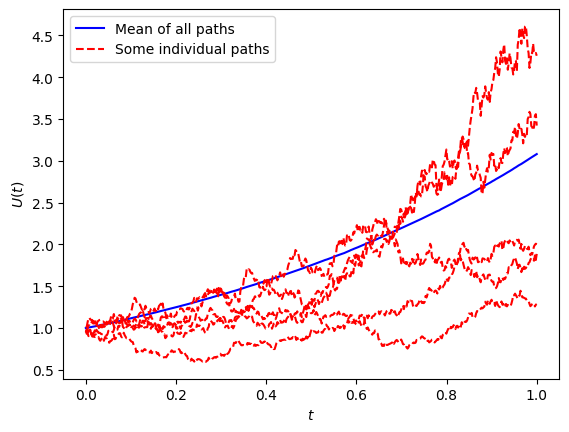

In [54]:
T = 1.0 # End time
N = 500 # Number of steps
dt = T / N
t = np.linspace(0, T, N)

M = 10000 # Will construct M paths simultaneously

dW = np.sqrt(dt) * np.random.randn(M, N) # Now construct the increments for all points and paths
W = np.cumsum(dW, 1) # Take the cumulative sum for each path separately

U = np.exp(t + 0.5*W) # Construct a function of the Brownian path
Umean = np.mean(U, 0) # Take the mean across all paths

# Compare against the expected average solution
print("Average error is {}".format(np.linalg.norm((Umean - np.exp(9*t/8)), np.inf)))

plt.plot(t, Umean, 'b-')
for i in range(5):
    plt.plot(t, U[i, :], 'r--')
plt.xlabel(r'$t$')
plt.ylabel(r'$U(t)$')
plt.legend(('Mean of all paths', 'Some individual paths'), loc = 'upper left')

plt.show()